# Pytensor and scipy optimization

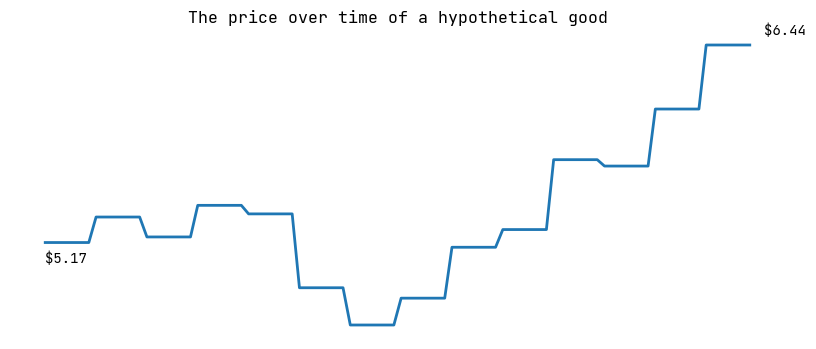

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
import arviz as az
import ipywidgets as widgets
import warnings
from pymc import vectorize_over_posterior
from pytensor.graph import graph_replace

def build_ar_process(
    n_days=100,
    noise=0.3,
    initial_price=5.0
):
    """
    Build an autoregressive process with repulsion away from 0.
    """
    rng = np.random.default_rng(1234)
    noise = rng.normal(0, noise, n_days)
    beta = 0.95
    repulsion_strength = 0.1

    prices = np.zeros(n_days)
    prices[0] = initial_price

    for i in range(1, n_days):
        repulsive_force = repulsion_strength / prices[i-1]**2
        prices[i] = prices[i-1] + beta * noise[i] + repulsive_force

    return prices

plt.figure(figsize=(10,4))

prices = build_ar_process(noise=0.1,)
prices_new = []
for i in range(int(len(prices)/7)):
    mean = np.mean(prices[i*7:(i+1)*7])
    prices_new.extend([mean]*7)
prices = np.array(prices_new)
plt.plot(prices, linewidth=2)

last_value = prices[-1]
plt.text(
    99,
    last_value*1.01,
    f'${round(last_value,2)}',
    fontsize=10,
)
first_value = prices[0]
plt.text(
    0,
    first_value*0.975,
    f'${round(first_value,2)}',
    fontsize=10,
)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.xticks([])
plt.yticks([])
plt.title("The price over time of a hypothetical good");

In [2]:
#| echo: true

# dividing by the mean is like subtracting the mean in additive
# models - it decorrelates intercept and predictor
prices_centered = prices / np.mean(prices)

with pm.Model() as model:
    a = pm.Gamma("a", mu=100, sigma=40)
    b = pm.Normal("b", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    prices_pt = pm.Data('x',prices_centered)

    mu = pm.Deterministic('mu',a * prices_pt ** b)

    y = pm.Normal("sales", mu=mu, sigma=sigma)

In [3]:
#| echo: true
a_true = 100
b_true = -1.1
sigma_true = 2
intervention_model = pm.do(model,{'a':a_true,'b':b_true,'sigma':sigma_true})
observed_sales = pm.draw(intervention_model.sales)

In [4]:
#| echo: true

with pm.observe(model,{"sales":observed_sales}):
    trace = pm.sample(nuts_sampler="nutpie",progressbar=False)

In [5]:
az.summary(trace,var_names=['a','b'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,99.904,0.212,99.526,100.309,0.003,0.004,5551.0,3063.0,1.0
b,-1.083,0.027,-1.136,-1.034,0.000,0.000,5483.0,2813.0,1.0


In [20]:
#| echo: true
# convert demand function to profit function
# unit_profit = unit_price - unit_cost
# total_profit = unit_profit * demand

# c is the unit_cost
c = pt.as_tensor(0.3)
unit_profit = (model.x - c)

# model.mu is the demand
objective = unit_profit * model.mu

# flip sign for optimization
objective = -1 * objective

exact solution:  3.306532663316583


Text(0.5, 0, 'Price')

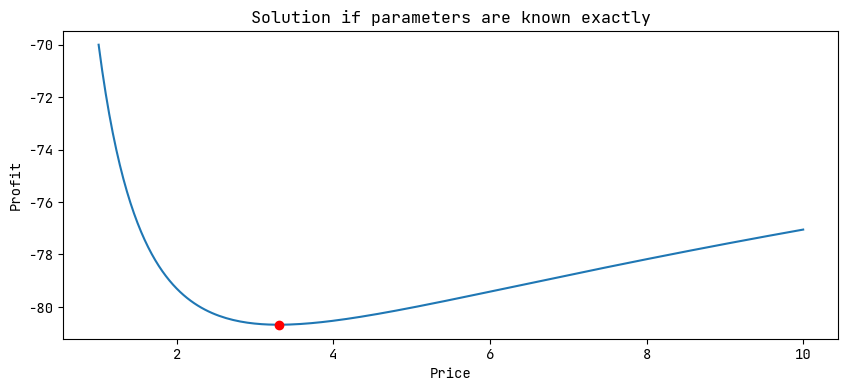

In [21]:
x = np.linspace(1,10,200)
y = 100 * x**-0.1 - 30 * x ** -1.1
y = -y

min_id = np.argmin(y)
exact_min_val = np.min(y)
exact_min_loc = x[min_id]
print("exact solution: ", exact_min_loc)

plt.figure(figsize=(10,4))
plt.plot(x,y)
plt.plot(exact_min_loc,exact_min_val,'ro')
plt.title("Solution if parameters are known exactly")
plt.ylabel("Profit")
plt.xlabel("Price")

In [22]:
#| echo: true
from pymc import vectorize_over_posterior

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

In [23]:
#| echo: true
objective = pt.mean(objective)

In [24]:
#| echo: true
from pytensor.graph import graph_replace

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

In [25]:
#| echo: true
# build gradient and objective function
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

Minimum using the expectation of the posterior:  3.9396984924623117


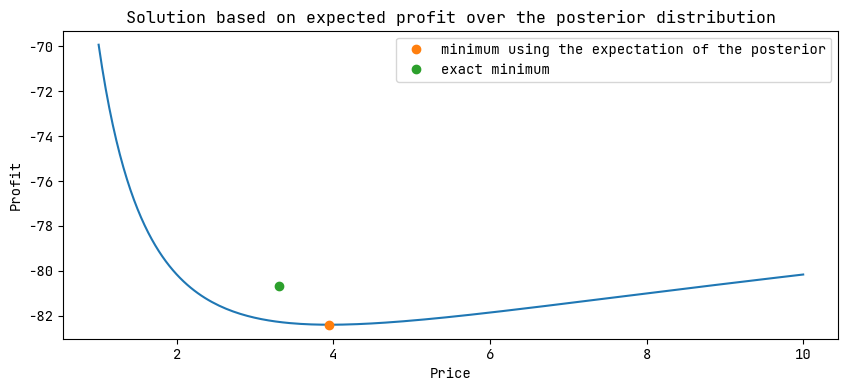

In [26]:
xs = np.linspace(1,10,200)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print("Minimum using the expectation of the posterior: ", min_loc)

plt.figure(figsize=(10,4))
plt.plot(xs,y)
plt.plot(min_loc,min_val,'o',label="minimum using the expectation of the posterior")
plt.plot(exact_min_loc,exact_min_val,'o',label="exact minimum")
plt.legend()
plt.ylabel("Profit")
plt.xlabel("Price")
plt.title("Solution based on expected profit over the posterior distribution");

Minimum using the expectation of the posterior:  3.9496042227099015


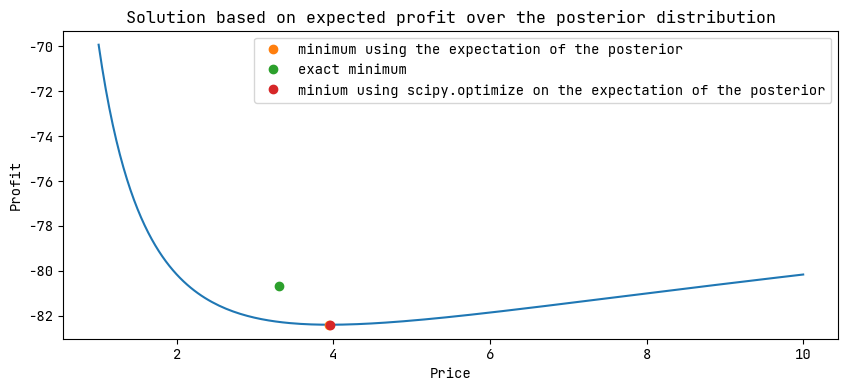

In [27]:
from scipy.optimize import minimize

res = minimize(
    objective_fn,
    jac=True,
    x0 = [2.50],
    bounds = [(0, None)]
)
print("Minimum using the expectation of the posterior: ", res.x[0])
plt.figure(figsize=(10,4))
plt.plot(xs,y)
plt.plot(min_loc,min_val,'o',label="minimum using the expectation of the posterior")
plt.plot(exact_min_loc,exact_min_val,'o',label="exact minimum")
plt.plot(res.x[0],res.fun,'o',label="minium using scipy.optimize on the expectation of the posterior")
plt.legend(loc="upper right")
plt.ylabel("Profit")
plt.xlabel("Price")
plt.title("Solution based on expected profit over the posterior distribution");

# Rich utility functions

Imagine that we sell the product at this price for one year and we need to make at least $28,500 to keep the lights on. We can visualize the uncertainty in profits for a range of prices:

## Uncertainty window

Text(0.5, 1.0, 'Uncertainty in profits over one year')

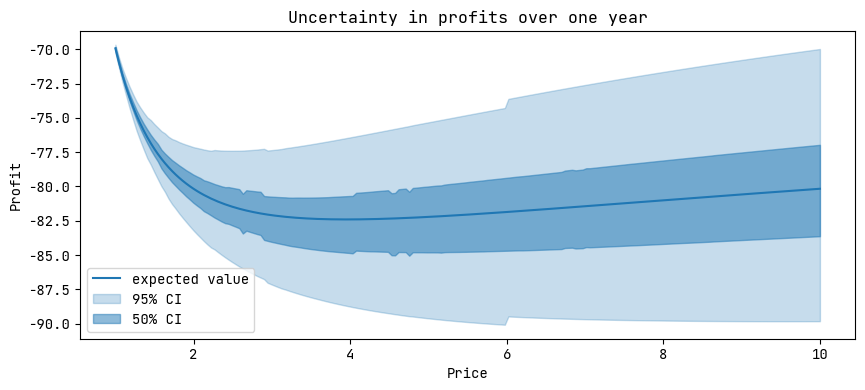

In [28]:
c = pt.as_tensor(0.3)
unit_profit = (model.x - c)

objective = unit_profit * model.mu
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

# objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective])

y = [objective_fn([x])[0] for x in xs]
y = np.array(y)
y = np.reshape(y,(200,4000)).T

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hdis_95 = az.hdi(y,hdi_prob=0.95)
    hdis_50 = az.hdi(y,hdi_prob=0.50)

lower_95 = hdis_95[:,0]
upper_95 = hdis_95[:,1]

lower_50 = hdis_50[:,0]
upper_50 = hdis_50[:,1]

plt.figure(figsize=(10,4))
plt.plot(xs,y.mean(axis=0),label="expected value")
plt.fill_between(xs,lower_95,upper_95,alpha=0.25,label="95% CI",color="tab:blue");
plt.fill_between(xs,lower_50,upper_50,alpha=0.5,label="50% CI",color="tab:blue");
plt.legend()
plt.ylabel("Profit")
plt.xlabel("Price")
plt.title("Uncertainty in profits over one year")

## Expected utility models of risk aversions

### Exponential utility

Text(0.5, 1.0, 'Exponential utility function')

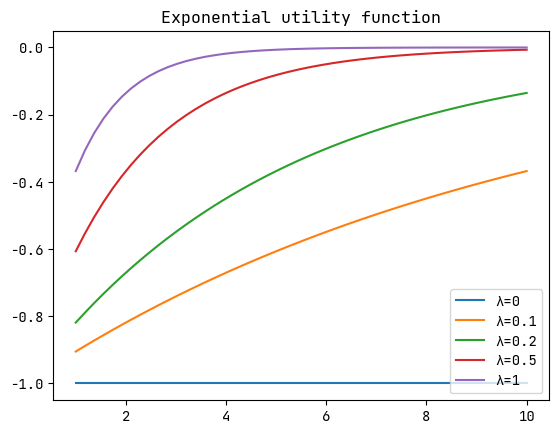

In [15]:
x = np.linspace(1,10)

lams = [0,0.1,0.2,0.5,1]
for lam in lams:
    exp_utility = -np.exp(-lam*x)
    plt.plot(x,exp_utility,label=f"λ={lam}")
plt.legend(loc="lower right")
plt.title("Exponential utility function")

In [ ]:
import ipywidgets as widgets
from IPython.display import display

c = pt.as_tensor(0.3)
lam = pt.scalar("lam") # new - risk adversion parameter
unit_profit = (model.x - c)

objective = unit_profit * model.mu
objective = pt.switch( # new - exponential utility
    pt.eq(lam,0),
    objective,
    -pt.exp(-lam * objective)
)
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

# objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x,lam], [objective])

# Create a slider widget for lambda (risk aversion)
lambda_slider = widgets.FloatSlider(
    value=0.0,  # default value
    min=0.0,    # minimum
    max=0.2,    # maximum
    step=0.01,
    description='λ (risk aversion):'
)

# Create an output widget to display the plot
output = widgets.Output()

# Define the update function
def update_plot(lam_val):
    output.clear_output(wait=True)
    with output:
        # Recalculate with new lambda value
        y = [objective_fn([x], lam_val)[0] for x in xs]
        y = np.array(y)
        y = np.reshape(y, (200, 4000)).T
        y_mean = y.mean(axis=0)

        min_id = np.argmin(y_mean)
        min_val = np.min(y_mean)
        min_loc = xs[min_id]

        print("Optimal: ", min_loc)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            hdis_95 = az.hdi(y, hdi_prob=0.95)
            hdis_50 = az.hdi(y, hdi_prob=0.50)

        lower_95 = hdis_95[:, 0]
        upper_95 = hdis_95[:, 1]
        lower_50 = hdis_50[:, 0]
        upper_50 = hdis_50[:, 1]

        plt.figure(figsize=(10, 4))
        plt.plot(xs, y.mean(axis=0))
        plt.plot(min_loc, min_val, 'ro', label="minimum using expected utility")
        plt.fill_between(xs, lower_95, upper_95, alpha=0.25, label="95% CI", color="tab:blue")
        plt.fill_between(xs, lower_50, upper_50, alpha=0.5, label="50% CI", color="tab:blue")
        plt.legend()
        plt.ylabel("Profit")
        plt.xlabel("Price")
        plt.title(f"Power utility function (λ={lam_val})")
        plt.show()

# Connect slider to update function
lambda_slider.observe(lambda change: update_plot(change['new']), names='value')

# Display the slider and output
display(lambda_slider, output)

# Show initial plot
update_plot(lambda_slider.value)

FloatSlider(value=0.0, description='λ (risk aversion):', max=0.2, step=0.01)

Output()

## Non-expected utility models of risk aversion

### Mean-variance optimization

In [ ]:
import ipywidgets as widgets
from IPython.display import display

c = pt.as_tensor(0.3)
lam = pt.scalar("lam") # new - risk adversion parameter
unit_profit = (model.x - c)

objective = unit_profit * model.mu

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

objective = pt.mean(objective) - lam * pt.var(objective)
objective = -1 * objective

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

# objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x,lam], [objective])

# Create a slider widget for lambda (risk aversion)
lambda_slider = widgets.FloatSlider(
    value=0.0,  # default value
    min=0.0,    # minimum
    max=10,    # maximum
    step=0.1,
    description='λ (risk aversion):'
)

# Create an output widget to display the plot
output = widgets.Output()

# Define the update function
def update_plot(lam_val):
    output.clear_output(wait=True)
    with output:
        # Recalculate with new lambda value
        y = [objective_fn([x], lam_val)[0] for x in xs]
        y = np.array(y)

        min_id = np.argmin(y)
        min_val = np.min(y)
        min_loc = xs[min_id]

        print("Optimal: ", min_loc)

        plt.figure(figsize=(10, 4))
        plt.plot(xs, y)
        plt.plot(min_loc, min_val, 'ro', label="minimum using the mean-variance objective")
        plt.fill_between(xs, lower_95, upper_95, alpha=0.25, label="95% CI", color="tab:blue")
        plt.fill_between(xs, lower_50, upper_50, alpha=0.5, label="50% CI", color="tab:blue")
        plt.legend()
        plt.ylabel("Profit")
        plt.xlabel("Price")
        plt.title(f"Mean-variance (λ={lam_val})")
        plt.show()

# Connect slider to update function
lambda_slider.observe(lambda change: update_plot(change['new']), names='value')

# Display the slider and output
display(lambda_slider, output)

# Show initial plot
update_plot(lambda_slider.value)

FloatSlider(value=0.0, description='λ (risk aversion):', max=10.0)

Output()

### CVaR

In [31]:
import ipywidgets as widgets
from IPython.display import display

c = pt.as_tensor(0.3)
p = pt.scalar("p") # new - risk adversion parameter
unit_profit = (model.x - c)

objective = unit_profit * model.mu

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# CVaR - drop all samples except the 5% in the tail and take the expectation
objective = objective.transpose((2,0,1))
objective = objective.flatten(ndim=(2))
objective = objective.sort(axis=1)
r = pt.floor(p * objective.shape[1])
r = pt.cast(r,"int32")
objective = objective[:,:r]

# Normal expectation minimization
objective = pt.mean(objective)
objective = -1 * objective

# objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

# objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x,p], [objective])

# Create a slider widget for lambda (risk aversion)
lambda_slider = widgets.FloatSlider(
    value=1.0,  # default value
    min=0.0,    # minimum
    max=1.0,    # maximum
    step=0.01,
    description='p percentile:'
)

# Create an output widget to display the plot
output = widgets.Output()

# Define the update function
def update_plot(p):
    output.clear_output(wait=True)
    with output:
        # Recalculate with new lambda value
        y = [objective_fn([x], p)[0] for x in xs]
        y = np.array(y)

        min_id = np.argmin(y)
        min_val = np.min(y)
        min_loc = xs[min_id]

        print("Optimal: ", min_loc)

        plt.figure(figsize=(10, 4))
        plt.plot(xs,y,label=f"expected value of lower {p*100}% percentile")
        plt.plot(min_loc, min_val, 'ro', label="minimum using CVaR")
        plt.fill_between(xs, lower_95, upper_95, alpha=0.25, label="95% CI", color="tab:blue")
        plt.fill_between(xs, lower_50, upper_50, alpha=0.5, label="50% CI", color="tab:blue")
        plt.legend()
        plt.ylabel("Profit")
        plt.xlabel("Price")
        plt.title(f"CVar (p={p})")
        plt.show()

# Connect slider to update function
lambda_slider.observe(lambda change: update_plot(change['new']), names='value')

# Display the slider and output
display(lambda_slider, output)

# Show initial plot
update_plot(lambda_slider.value)

FloatSlider(value=1.0, description='p percentile:', max=1.0, step=0.01)

Output()